# Задание 4. Построение оптимального портфеля

## Модель Тобина-Шарпа-Линтнера

В этом ноутбуке выполнено задание по построению оптимального портфеля из шести акций:
**GAZP, ROSN, LKOH, FEES, SBER, VTBR**.

Что делает ноутбук:

1. безопасно подготавливает данные из исходного Excel-файла;
2. запускает основной MATLAB/Octave-скрипт `task4_portfolio_tsl.m`;
3. считывает рассчитанные таблицы из папки `results`;
4. показывает эффективные границы и оптимальные портфели;
5. формулирует выводы по влиянию ограничений и смыслу коэффициента \(\xi\).

Исходный файл `Data_zad4_2026.xlsx` **не изменяется**.


## Текст задания в кратком виде

Требуется рассчитать по ценам закрытия вектор ожидаемых доходностей \(m\) и ковариационную матрицу \(C\)
для шести бумаг. В качестве безрискового актива используется депозит по ставке ЦБ РФ.
При заимствовании ставка равна ставке ЦБ плюс 5 процентных пунктов.

Дополнительно заданы ограничения:

- индивидуальные ограничения на каждую бумагу \(L_i \le x_i \le U_i\);
- групповые ограничения \(g_l \le Gx \le g_u\);
- ограничения типа `GroupComparison`, задающие отношение двух групп активов.

Нужно построить эффективную границу и определить оптимальные портфели при разных коэффициентах
неприятия риска \(\theta\), где большее \(\theta\) соответствует более осторожному инвестору.


In [1]:
from pathlib import Path
import json
import shutil
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / "Data_zad4_2026.xlsx").exists() and (ROOT / "Finance/4/Data_zad4_2026.xlsx").exists():
    ROOT = ROOT / "Finance/4"

PREPARED_DIR = ROOT / "prepared"
RESULTS_DIR = ROOT / "results"
ASSETS = ["GAZP", "ROSN", "LKOH", "FEES", "SBER", "VTBR"]
ASSET_COLORS = {
    "GAZP": "#2563eb",
    "ROSN": "#16a34a",
    "LKOH": "#dc2626",
    "FEES": "#f59e0b",
    "SBER": "#059669",
    "VTBR": "#7c3aed",
}

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("default")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["font.family"] = "DejaVu Sans"

print(f"Рабочая папка: {ROOT.resolve()}")
print(f"Octave: {shutil.which('octave')}")


Рабочая папка: /home/nikita/Code/MSU/Finance/4
Octave: /usr/bin/octave


## Важное замечание по датам

На скрине задания указан интервал `2016-04-01...2016-04-10`.
При этом в реально приложенном файле `Data_zad4_2026.xlsx` лежат данные за другой период.
Ниже это проверяется автоматически по подготовленному `metadata.json`.


In [2]:
prepare = subprocess.run(
    ["python", "prepare_data.py"],
    cwd=ROOT,
    text=True,
    capture_output=True,
    check=True,
)
print(prepare.stdout)

metadata = json.loads((PREPARED_DIR / "metadata.json").read_text(encoding="utf-8"))
display(pd.Series(metadata, name="metadata"))


Prepared 23 quote rows and 22 return rows in /home/nikita/Code/MSU/Finance/4/prepared



source_file                                            Data_zad4_2026.xlsx
source_sheet                                                    Исх_данные
source_rows_nonempty                                                    24
quote_rows                                                              23
return_rows                                                             22
date_from                                                       2010-09-01
date_to                                                         2010-10-01
asset_order                           [GAZP, ROSN, LKOH, FEES, SBER, VTBR]
index_column                                                         MICEX
trading_days_per_year                                                  252
note                     The screenshot mentions 2016-04-01..2016-04-10...
Name: metadata, dtype: object

## Подготовленные цены

Данные приведены к удобному виду: одна дата — одна строка, тикеры — отдельные столбцы.
Отдельно сохранены простые дневные доходности:

\[
r_{t,i} = \frac{P_{t,i}}{P_{t-1,i}} - 1.
\]


In [3]:
quotes = pd.read_csv(PREPARED_DIR / "quotes.csv", parse_dates=["date"])
returns = pd.read_csv(PREPARED_DIR / "returns_simple.csv", parse_dates=["date"])

display(Markdown("### Цены закрытия"))
display(quotes)

display(Markdown("### Простые дневные доходности"))
display(returns)


### Цены закрытия

,date,weekday,MICEX,GAZP,ROSN,LKOH,FEES,SBER,VTBR
0,2010-09-01,ср,1394.57,161.79,199.86,1656.18,0.354,80.42,0.0826
1,2010-09-02,чт,1401.81,162.80,201.46,1676.00,0.361,80.63,0.0828
2,2010-09-03,пт,1410.16,163.00,202.50,1674.01,0.365,81.72,0.0844
3,2010-09-06,пн,1408.64,162.95,202.00,1669.94,0.366,81.74,0.0848
4,2010-09-07,вт,1398.70,161.54,198.99,1671.00,0.361,79.95,0.0836
5,2010-09-08,ср,1422.08,164.14,203.20,1678.00,0.367,82.18,0.0855
6,2010-09-09,чт,1437.47,165.53,206.20,1715.00,0.364,83.66,0.0883
7,2010-09-10,пт,1433.82,164.40,205.69,1713.00,0.362,83.36,0.0886
8,2010-09-13,пн,1441.58,165.00,205.51,1713.51,0.363,84.59,0.0899
9,2010-09-14,вт,1433.22,163.00,203.88,1703.00,0.364,84.50,0.0896


### Простые дневные доходности

,date,GAZP,ROSN,LKOH,FEES,SBER,VTBR
0,2010-09-02,0.006243,0.008006,0.011967,0.019774,0.002611,0.002421
1,2010-09-03,0.001229,0.005162,-0.001187,0.011080,0.013519,0.019324
2,2010-09-06,-0.000307,-0.002469,-0.002431,0.002740,0.000245,0.004739
3,2010-09-07,-0.008653,-0.014901,0.000635,-0.013661,-0.021899,-0.014151
4,2010-09-08,0.016095,0.021157,0.004189,0.016620,0.027892,0.022727
5,2010-09-09,0.008468,0.014764,0.022050,-0.008174,0.018009,0.032749
6,2010-09-10,-0.006827,-0.002473,-0.001166,-0.005495,-0.003586,0.003398
7,2010-09-13,0.003650,-0.000875,0.000298,0.002762,0.014755,0.014673
8,2010-09-14,-0.012121,-0.007931,-0.006134,0.002755,-0.001064,-0.003337
9,2010-09-15,0.005337,-0.016235,0.010558,0.010989,-0.000592,-0.005580


## Инфографика 1. Что происходило с бумагами

Перед оптимизацией полезно посмотреть на сами данные: нормированные цены, накопленную доходность и дневные колебания.
Это помогает понять, почему оптимизатор дальше так охотно выбирает SBER, VTBR и LKOH, а GAZP получает минимальную долю.


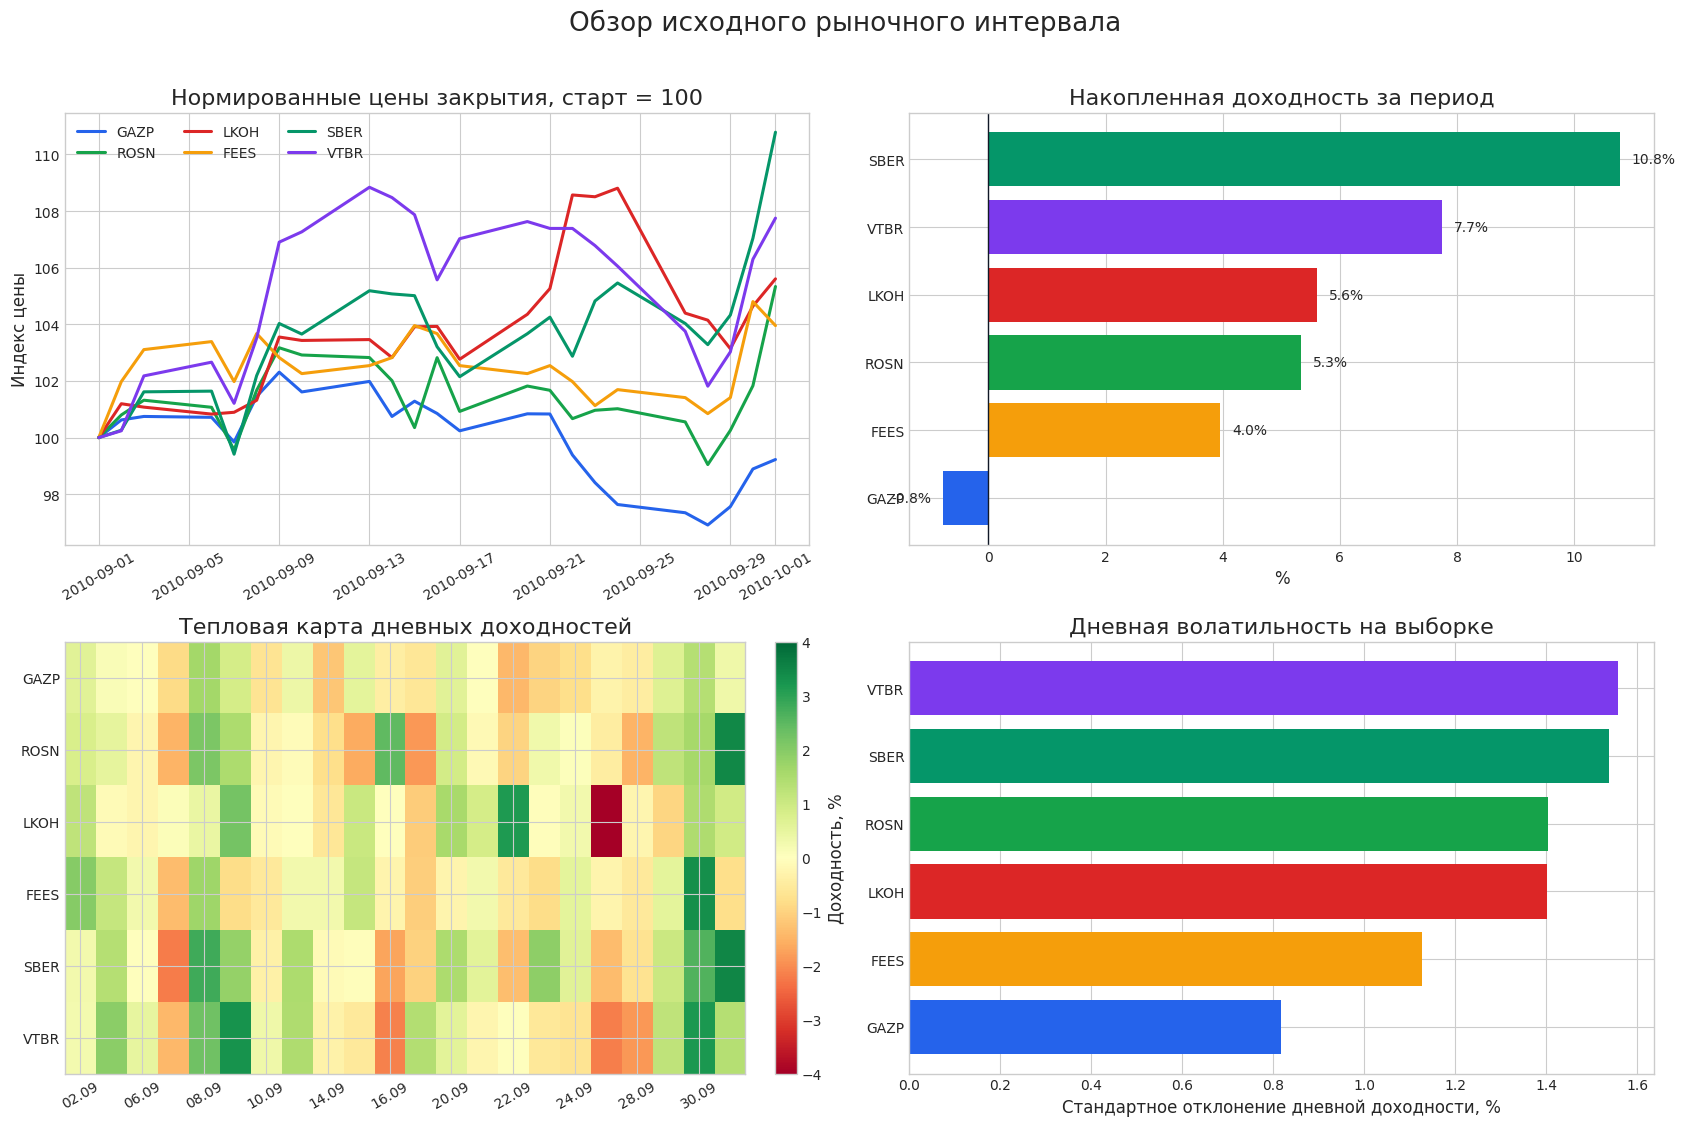

In [4]:
norm_prices = quotes.set_index("date")[ASSETS] / quotes.set_index("date")[ASSETS].iloc[0] * 100
cumulative = (1 + returns.set_index("date")[ASSETS]).cumprod() - 1
returns_matrix = returns.set_index("date")[ASSETS] * 100

fig, axes = plt.subplots(2, 2, figsize=(17, 11))

ax = axes[0, 0]
for asset in ASSETS:
    ax.plot(norm_prices.index, norm_prices[asset], label=asset, linewidth=2.2, color=ASSET_COLORS[asset])
ax.set_title("Нормированные цены закрытия, старт = 100")
ax.set_ylabel("Индекс цены")
ax.legend(ncol=3)
ax.tick_params(axis="x", rotation=30)

ax = axes[0, 1]
final_cum = cumulative.iloc[-1].sort_values()
bars = ax.barh(final_cum.index, final_cum.values * 100, color=[ASSET_COLORS[a] for a in final_cum.index])
ax.axvline(0, color="#111827", linewidth=1)
ax.set_title("Накопленная доходность за период")
ax.set_xlabel("%")
for bar in bars:
    width = bar.get_width()
    ax.text(width + (0.2 if width >= 0 else -0.2), bar.get_y() + bar.get_height() / 2, f"{width:.1f}%", va="center", ha="left" if width >= 0 else "right")

ax = axes[1, 0]
im = ax.imshow(returns_matrix.T, aspect="auto", cmap="RdYlGn", vmin=-4, vmax=4)
ax.set_title("Тепловая карта дневных доходностей")
ax.set_yticks(range(len(ASSETS)))
ax.set_yticklabels(ASSETS)
step = max(1, len(returns_matrix.index) // 8)
tick_pos = list(range(0, len(returns_matrix.index), step))
ax.set_xticks(tick_pos)
ax.set_xticklabels([returns_matrix.index[i].strftime("%d.%m") for i in tick_pos], rotation=30)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Доходность, %")

ax = axes[1, 1]
daily_vol = returns.set_index("date")[ASSETS].std().sort_values() * 100
ax.barh(daily_vol.index, daily_vol.values, color=[ASSET_COLORS[a] for a in daily_vol.index])
ax.set_title("Дневная волатильность на выборке")
ax.set_xlabel("Стандартное отклонение дневной доходности, %")

fig.suptitle("Обзор исходного рыночного интервала", y=1.02, fontsize=19)
plt.tight_layout()
overview_path = RESULTS_DIR / "infographic_market_overview.png"
fig.savefig(overview_path, dpi=180, bbox_inches="tight")
plt.show()


## Запуск MATLAB/Octave-расчёта

Основной расчёт вынесен в файл `task4_portfolio_tsl.m`.
Он совместим с GNU Octave и использует встроенную функцию квадратичной оптимизации `qp`,
поэтому дополнительные пакеты `octave-optim` и `octave-io` не требуются.


In [5]:
octave_cmd = ["octave", "--no-gui", "task4_portfolio_tsl.m"]
octave = subprocess.run(
    octave_cmd,
    cwd=ROOT,
    text=True,
    capture_output=True,
    check=True,
)

print(octave.stdout)
if octave.stderr.strip():
    print("STDERR:")
    print(octave.stderr)



Annualized estimates:
Asset            Return           Risk
GAZP           -8.0788%       12.9818%
ROSN           61.9481%       22.2884%
LKOH           64.9190%       22.2643%
FEES           45.9806%       17.8956%
SBER          120.3744%       24.3993%
VTBR           88.5344%       24.7424%

Optimal portfolios:
Scenario           theta case           return       risk       xi
asset_limits           2 borrowing     135.73%     32.25%    2.000
asset_limits           3 borrowing     135.73%     32.25%    2.000
asset_limits           4 borrowing     135.73%     32.25%    2.000
asset_limits           8 borrowing     135.73%     32.25%    2.000
asset_limits          12 borrowing     122.19%     28.04%    1.685
asset_limits          20 borrowing      87.58%     18.31%    1.058
asset_limits          40 lending        60.93%     12.05%    0.665
group_limits           2 borrowing      90.63%     20.67%    1.200
group_limits           3 borrowing      90.63%     20.67%    1.200
group_limits 

## Оценки доходности и риска

Оценки считаются по дневным доходностям и годятся на 252 торговых дня:

\[
m_i = 252\cdot \bar r_i,
\qquad
C = 252\cdot \operatorname{cov}(r).
\]


In [6]:
estimates = pd.read_csv(RESULTS_DIR / "asset_estimates.csv")
estimates_display = estimates.copy()
for col in ["ExpectedDailyReturn", "ExpectedAnnualReturn", "AnnualVolatility"]:
    estimates_display[col] = (100 * estimates_display[col]).map(lambda x: f"{x:.2f}%")
display(estimates_display)

cov = pd.read_csv(RESULTS_DIR / "covariance_annual.csv", index_col=0)
display(Markdown("### Годовая ковариационная матрица"))
display(cov.style.format("{:.6f}"))


,Ticker,ExpectedDailyReturn,ExpectedAnnualReturn,AnnualVolatility
0,GAZP,-0.03%,-8.08%,12.98%
1,ROSN,0.25%,61.95%,22.29%
2,LKOH,0.26%,64.92%,22.26%
3,FEES,0.18%,45.98%,17.90%
4,SBER,0.48%,120.37%,24.40%
5,VTBR,0.35%,88.53%,24.74%


### Годовая ковариационная матрица

,GAZP,ROSN,LKOH,FEES,SBER,VTBR
Asset,,,,,,
GAZP,0.016853,0.016227,0.005624,0.014578,0.020847,0.020694
ROSN,0.016227,0.049677,0.010978,0.010871,0.036142,0.023243
LKOH,0.005624,0.010978,0.049570,0.006413,0.016827,0.022295
FEES,0.014578,0.010871,0.006413,0.032025,0.017747,0.017574
SBER,0.020847,0.036142,0.016827,0.017747,0.059533,0.043718
VTBR,0.020694,0.023243,0.022295,0.017574,0.043718,0.061219


## Инфографика 2. Риск, доходность и связь бумаг

На диаграмме риск-доходность хорошо видна исходная асимметрия данных:
GAZP имеет отрицательную ожидаемую доходность, а SBER и VTBR выглядят наиболее привлекательными по выборочной доходности.
Корреляционная матрица показывает, насколько бумаги двигались синхронно на данном коротком интервале.


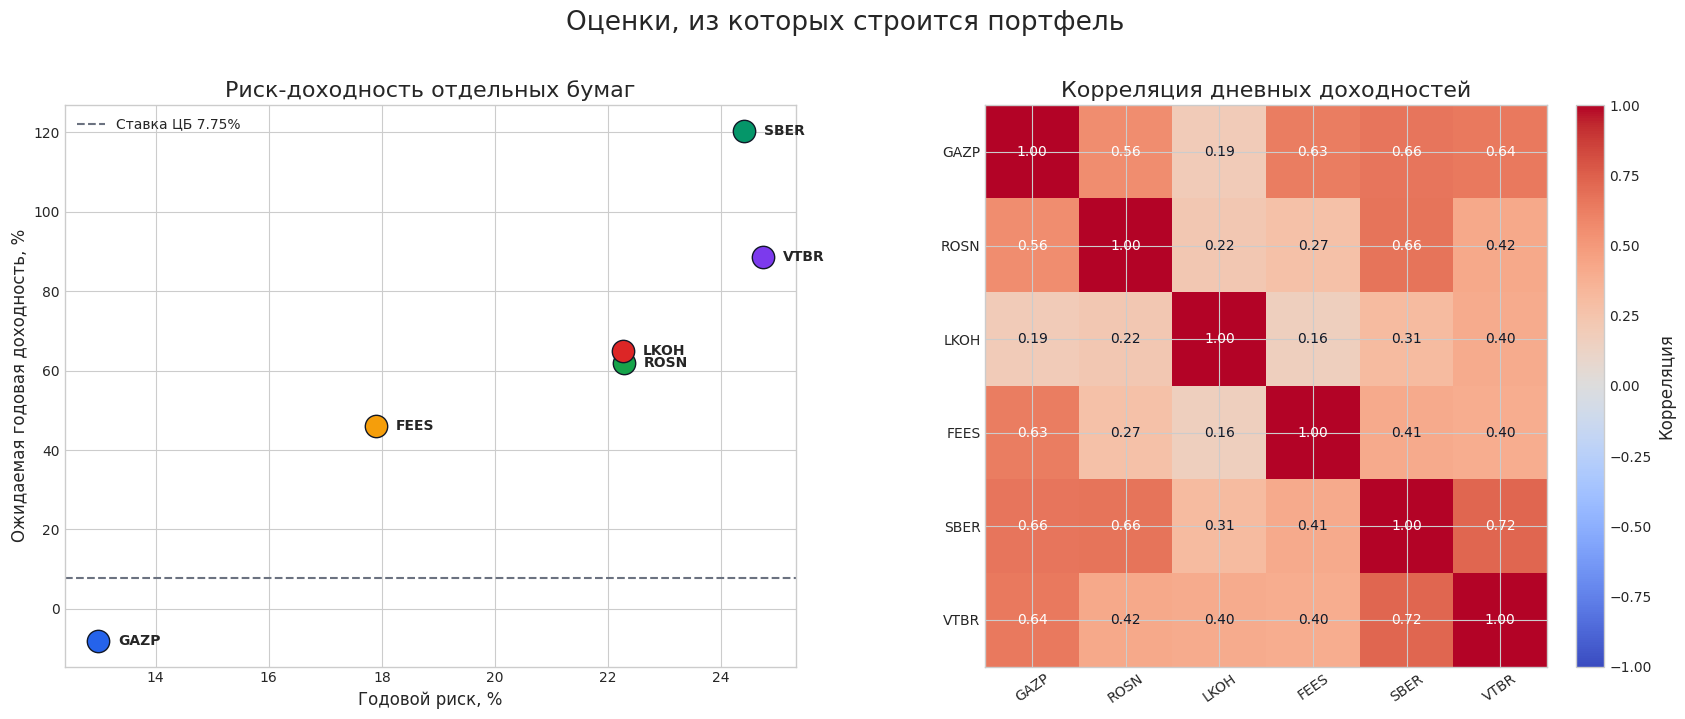

In [7]:
corr = returns.set_index("date")[ASSETS].corr()
est_plot = estimates.set_index("Ticker").loc[ASSETS].copy()
est_plot["ExpectedAnnualReturnPct"] = 100 * est_plot["ExpectedAnnualReturn"]
est_plot["AnnualVolatilityPct"] = 100 * est_plot["AnnualVolatility"]

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

ax = axes[0]
for asset, row in est_plot.iterrows():
    ax.scatter(
        row["AnnualVolatilityPct"],
        row["ExpectedAnnualReturnPct"],
        s=260,
        color=ASSET_COLORS[asset],
        edgecolor="#111827",
        linewidth=1.0,
        zorder=3,
    )
    ax.text(row["AnnualVolatilityPct"] + 0.35, row["ExpectedAnnualReturnPct"], asset, va="center", fontweight="bold")
ax.axhline(7.75, color="#6b7280", linestyle="--", linewidth=1.5, label="Ставка ЦБ 7.75%")
ax.set_title("Риск-доходность отдельных бумаг")
ax.set_xlabel("Годовой риск, %")
ax.set_ylabel("Ожидаемая годовая доходность, %")
ax.legend()

ax = axes[1]
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_title("Корреляция дневных доходностей")
ax.set_xticks(range(len(ASSETS)))
ax.set_xticklabels(ASSETS, rotation=35)
ax.set_yticks(range(len(ASSETS)))
ax.set_yticklabels(ASSETS)
for i in range(len(ASSETS)):
    for j in range(len(ASSETS)):
        val = corr.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="white" if abs(val) > 0.55 else "#111827", fontsize=10)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Корреляция")

fig.suptitle("Оценки, из которых строится портфель", y=1.02, fontsize=19)
plt.tight_layout()
risk_corr_path = RESULTS_DIR / "infographic_risk_correlation.png"
fig.savefig(risk_corr_path, dpi=180, bbox_inches="tight")
plt.show()


## Ограничения

В расчёте используются три набора ограничений.

**1. Индивидуальные ограничения**

\[
0.05 \le x_i \le 0.39.
\]

**2. Групповые ограничения**

Порядок активов: `GAZP`, `ROSN`, `LKOH`, `FEES`, `SBER`, `VTBR`.

\[
G =
\begin{bmatrix}
1 & 1 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 1 \\
0 & 0 & 1 & 1 & 1 & 1 \\
1 & 1 & 0 & 0 & 0 & 0
\end{bmatrix}.
\]

Строки: нефтегаз, энергетика, банки, внутренний рынок, внешний рынок.

**3. GroupComparison**

В скрине приведена формула, но не даны конкретные численные границы \(l_i, u_i\).
Поэтому в расчёте явно зафиксирован параметризуемый вариант:

- внутренний рынок / внешний рынок: от 1 до 5;
- нефтегаз / банки: от 0.8 до 3.


## Эффективные границы

График показывает, как добавление ограничений сдвигает допустимую область портфелей.


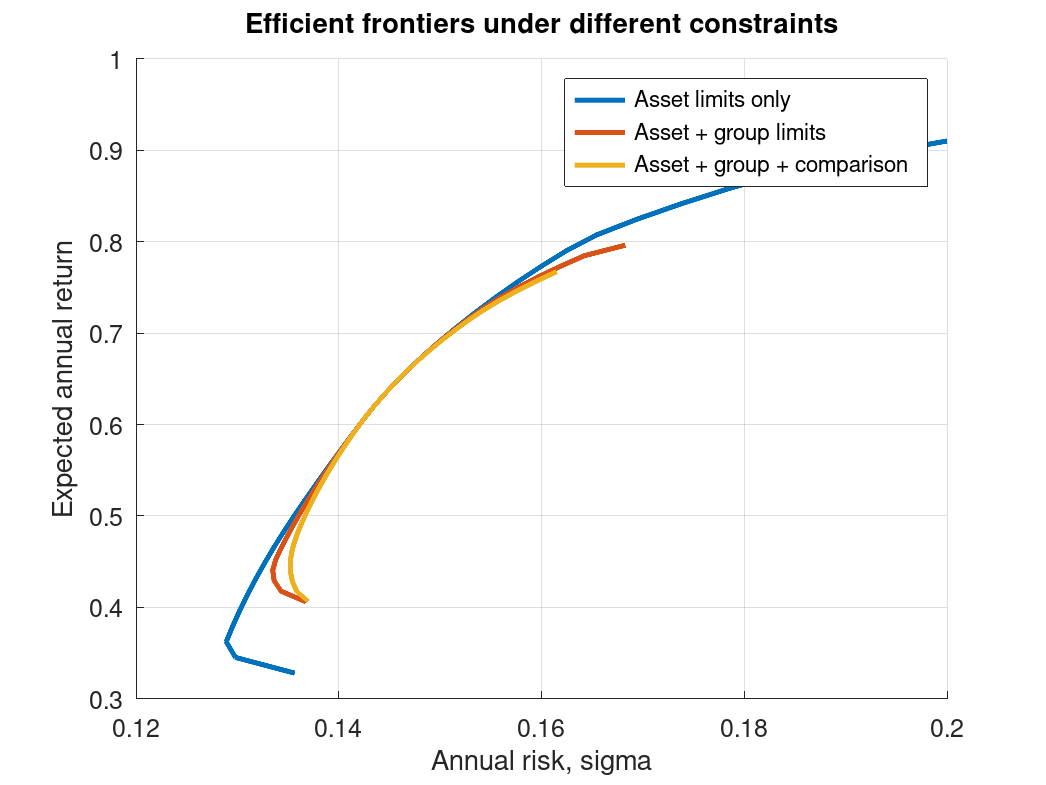

In [8]:
display(Image(filename=str(RESULTS_DIR / "efficient_frontiers.png")))

frontier = pd.read_csv(RESULTS_DIR / "frontier_points.csv")
display(frontier.groupby("Scenario")[["RiskAnnual", "ReturnAnnual"]].agg(["min", "max"]).style.format("{:.4f}"))


## Оптимальные портфели

Для заданного \(\theta\) максимизируется функция полезности:

\[
U(x) = r_f x_0 + m^\top x - \frac{\theta}{2}x^\top Cx,
\qquad
x_0 = 1 - \sum_i x_i.
\]

Если \(x_0 \ge 0\), свободная часть капитала размещается в безрисковый депозит.
Если \(x_0 < 0\), используется заимствование по ставке ЦБ + 5 п.п.


In [9]:
optimal = pd.read_csv(RESULTS_DIR / "optimal_portfolios.csv")

percent_cols = ["ExpectedReturnAnnual", "RiskAnnual", "RiskFreeWeight", *ASSETS]
display_cols = ["Scenario", "Theta", "RiskFreeCase", "ExpectedReturnAnnual", "RiskAnnual", "XiRiskyAllocation", "RiskFreeWeight", *ASSETS]
optimal_display = optimal[display_cols].copy()
for col in percent_cols:
    optimal_display[col] = (100 * optimal_display[col]).map(lambda x: f"{x:.2f}%")
optimal_display["XiRiskyAllocation"] = optimal_display["XiRiskyAllocation"].map(lambda x: f"{x:.3f}")

display(optimal_display)


,Scenario,Theta,RiskFreeCase,ExpectedReturnAnnual,RiskAnnual,XiRiskyAllocation,RiskFreeWeight,GAZP,ROSN,LKOH,FEES,SBER,VTBR
0,asset_limits,2,borrowing,135.73%,32.25%,2.000,-100.00%,5.00%,39.00%,39.00%,39.00%,39.00%,39.00%
1,asset_limits,3,borrowing,135.73%,32.25%,2.000,-100.00%,5.00%,39.00%,39.00%,39.00%,39.00%,39.00%
2,asset_limits,4,borrowing,135.73%,32.25%,2.000,-100.00%,5.00%,39.00%,39.00%,39.00%,39.00%,39.00%
3,asset_limits,8,borrowing,135.73%,32.25%,2.000,-100.00%,5.00%,39.00%,39.00%,39.00%,39.00%,39.00%
4,asset_limits,12,borrowing,122.19%,28.04%,1.685,-68.47%,5.00%,19.83%,39.00%,26.64%,39.00%,39.00%
5,asset_limits,20,borrowing,87.58%,18.31%,1.058,-5.81%,5.00%,5.00%,28.71%,11.36%,39.00%,16.74%
6,asset_limits,40,lending,60.93%,12.05%,0.665,33.46%,5.00%,5.00%,12.81%,5.00%,33.72%,5.00%
7,group_limits,2,borrowing,90.63%,20.67%,1.200,-20.00%,5.00%,30.00%,5.00%,27.00%,39.00%,14.00%
8,group_limits,3,borrowing,90.63%,20.67%,1.200,-20.00%,5.00%,30.00%,5.00%,27.00%,39.00%,14.00%
9,group_limits,4,borrowing,90.63%,20.67%,1.200,-20.00%,5.00%,30.00%,5.00%,27.00%,39.00%,14.00%


## Инфографика 3. Как меняется состав портфеля

Сначала сравним три набора ограничений при среднем инвесторе \(\theta=3\).
Затем посмотрим, как полный набор ограничений реагирует на рост неприятия риска.


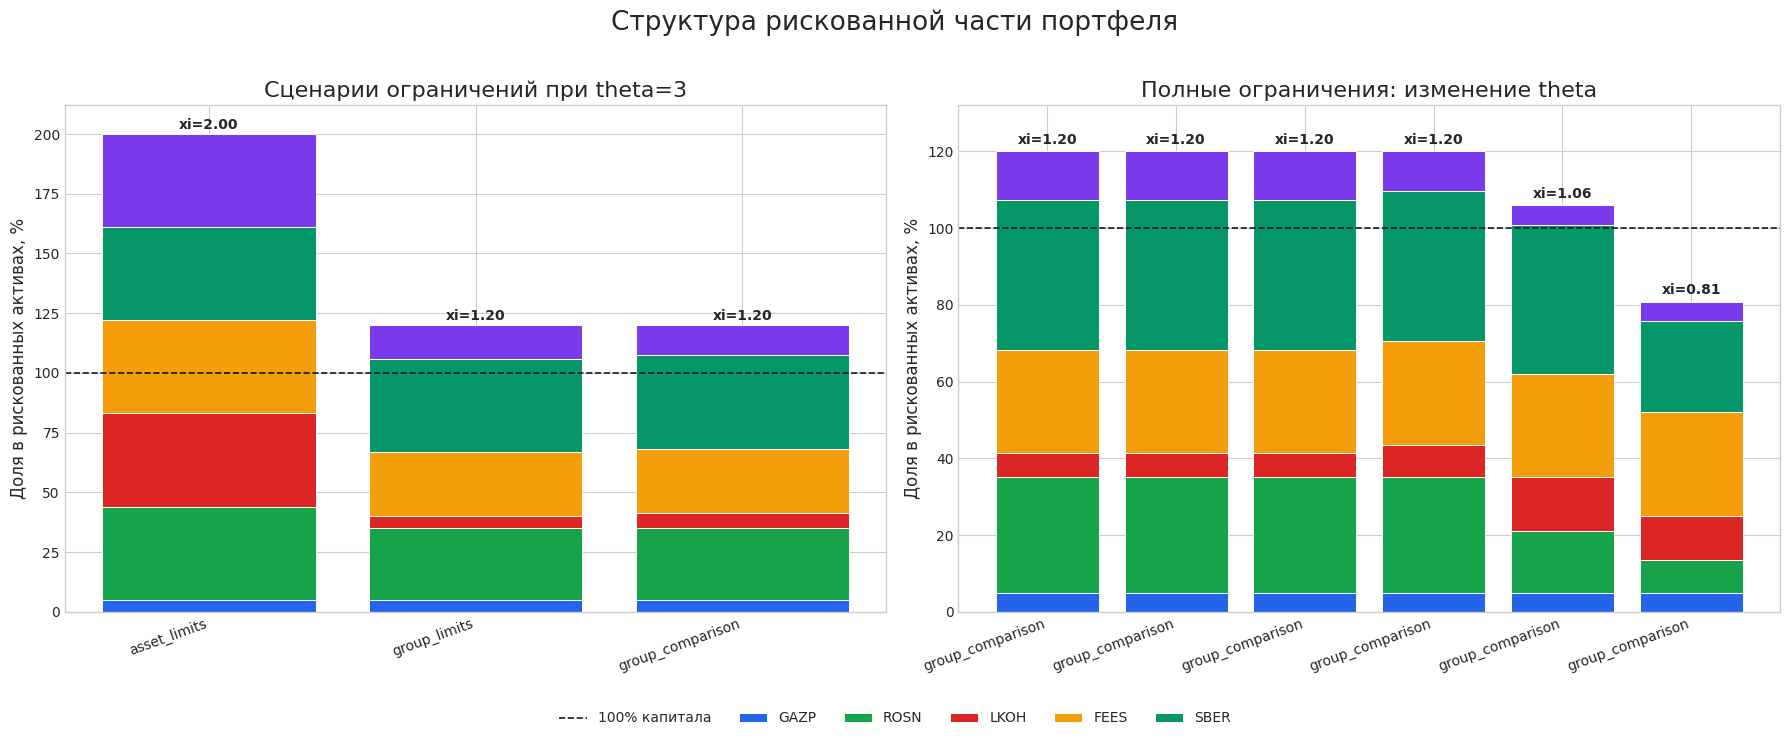

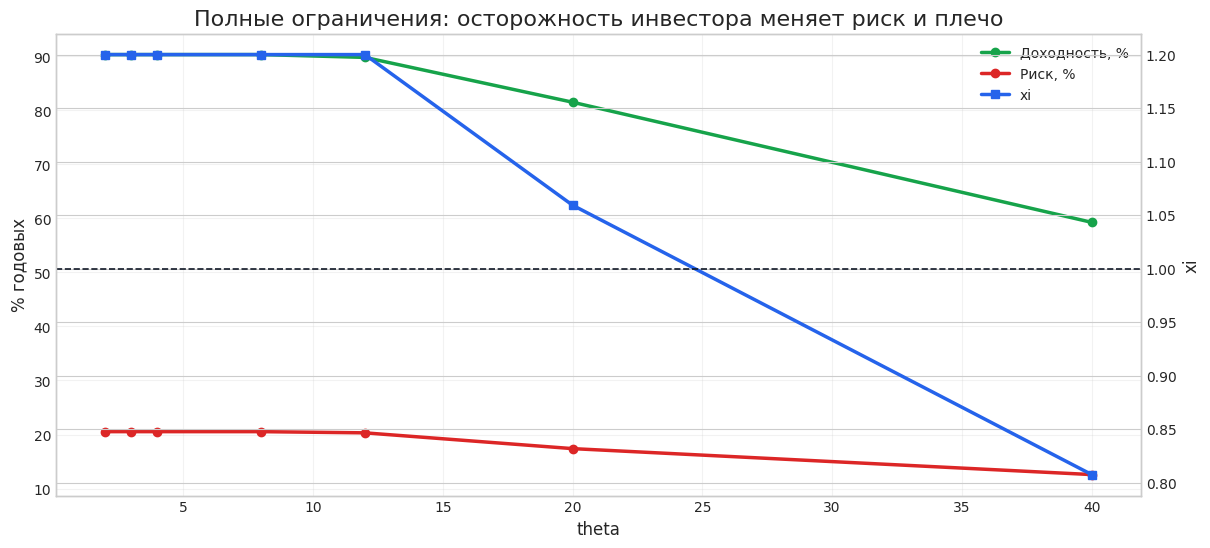

In [10]:
def stacked_weights(ax, frame, title):
    labels = frame["Scenario"].astype(str).tolist() if "Scenario" in frame else frame["Theta"].astype(str).tolist()
    x_pos = np.arange(len(frame))
    bottom = np.zeros(len(frame))
    for asset in ASSETS:
        vals = frame[asset].to_numpy() * 100
        ax.bar(x_pos, vals, bottom=bottom, label=asset, color=ASSET_COLORS[asset], edgecolor="white", linewidth=0.7)
        bottom += vals
    ax.axhline(100, color="#111827", linestyle="--", linewidth=1.2, label="100% капитала")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, rotation=20, ha="right")
    ax.set_ylabel("Доля в рискованных активах, %")
    ax.set_title(title)
    ax.set_ylim(0, max(125, bottom.max() + 12))
    for idx, total in enumerate(bottom):
        ax.text(idx, total + 2, f"xi={total/100:.2f}", ha="center", fontweight="bold")

theta3_raw = optimal.query("Theta == 3").copy()
full = optimal.query("Scenario == 'group_comparison'").sort_values("Theta").copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
stacked_weights(axes[0], theta3_raw, "Сценарии ограничений при theta=3")
stacked_weights(axes[1], full[full["Theta"].isin([2, 3, 4, 12, 20, 40])], "Полные ограничения: изменение theta")
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles[:len(ASSETS)], labels[:len(ASSETS)], ncol=6, loc="lower center", bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Структура рискованной части портфеля", y=1.02, fontsize=19)
plt.tight_layout(rect=(0, 0.05, 1, 1))
weights_path = RESULTS_DIR / "infographic_portfolio_weights.png"
fig.savefig(weights_path, dpi=180, bbox_inches="tight")
plt.show()

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(full["Theta"], full["ExpectedReturnAnnual"] * 100, marker="o", linewidth=2.5, label="Доходность, %", color="#16a34a")
ax1.plot(full["Theta"], full["RiskAnnual"] * 100, marker="o", linewidth=2.5, label="Риск, %", color="#dc2626")
ax1.set_xlabel("theta")
ax1.set_ylabel("% годовых")
ax1.set_title("Полные ограничения: осторожность инвестора меняет риск и плечо")
ax1.grid(alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(full["Theta"], full["XiRiskyAllocation"], marker="s", linewidth=2.5, label="xi", color="#2563eb")
ax2.axhline(1, color="#111827", linestyle="--", linewidth=1.2)
ax2.set_ylabel("xi")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
theta_path = RESULTS_DIR / "infographic_theta_sensitivity.png"
fig.savefig(theta_path, dpi=180, bbox_inches="tight")
plt.show()


## Сравнение ограничений

Чтобы увидеть, какие ограничения сильнее влияют на портфель, сравним три сценария при \(\theta=3\):

- только индивидуальные ограничения;
- индивидуальные + групповые;
- индивидуальные + групповые + `GroupComparison`.


In [11]:
theta3 = optimal.query("Theta == 3").copy()
theta3_display = theta3[display_cols].copy()
for col in percent_cols:
    theta3_display[col] = (100 * theta3_display[col]).map(lambda x: f"{x:.2f}%")
theta3_display["XiRiskyAllocation"] = theta3_display["XiRiskyAllocation"].map(lambda x: f"{x:.3f}")
display(theta3_display)


,Scenario,Theta,RiskFreeCase,ExpectedReturnAnnual,RiskAnnual,XiRiskyAllocation,RiskFreeWeight,GAZP,ROSN,LKOH,FEES,SBER,VTBR
1,asset_limits,3,borrowing,135.73%,32.25%,2.000,-100.00%,5.00%,39.00%,39.00%,39.00%,39.00%,39.00%
8,group_limits,3,borrowing,90.63%,20.67%,1.200,-20.00%,5.00%,30.00%,5.00%,27.00%,39.00%,14.00%
15,group_comparison,3,borrowing,90.32%,20.53%,1.200,-20.00%,5.00%,30.00%,6.33%,27.00%,39.00%,12.67%


## Активные ограничения

Ниже показаны ограничения, которые оказались активными для полного набора ограничений при \(\theta=3\).
Именно они сильнее всего формируют итоговый портфель.


In [12]:
activity = pd.read_csv(RESULTS_DIR / "constraint_activity.csv")
active = activity.query(
    "Scenario == 'group_comparison' and Theta == 3 and (ActiveLower == 1 or ActiveUpper == 1)"
).copy()
active["ActiveBound"] = np.where(active["ActiveLower"] == 1, "lower", "upper")
display(active[["ConstraintType", "Name", "Value", "LowerBound", "UpperBound", "ActiveBound"]].style.format({
    "Value": "{:.4f}",
    "LowerBound": "{:.4f}",
    "UpperBound": "{:.4f}",
}))


,ConstraintType,Name,Value,LowerBound,UpperBound,ActiveBound
195,Asset,GAZP,0.0500,0.0500,0.3900,lower
199,Asset,SBER,0.3900,0.0500,0.3900,upper
202,Group,Energy,0.2700,0.2700,0.7500,lower
204,Group,Internal,0.8500,0.2500,0.8500,upper
205,Group,External,0.3500,0.1000,0.3500,upper
207,GroupComparison,OilGasToBanks,0.8000,0.8000,3.0000,lower


## Инфографика 4. Какие ограничения держат портфель

На графике ниже диапазон показывает допустимые границы ограничения, а точка — найденное значение.
Если точка лежит у края диапазона, ограничение активно и реально влияет на результат.


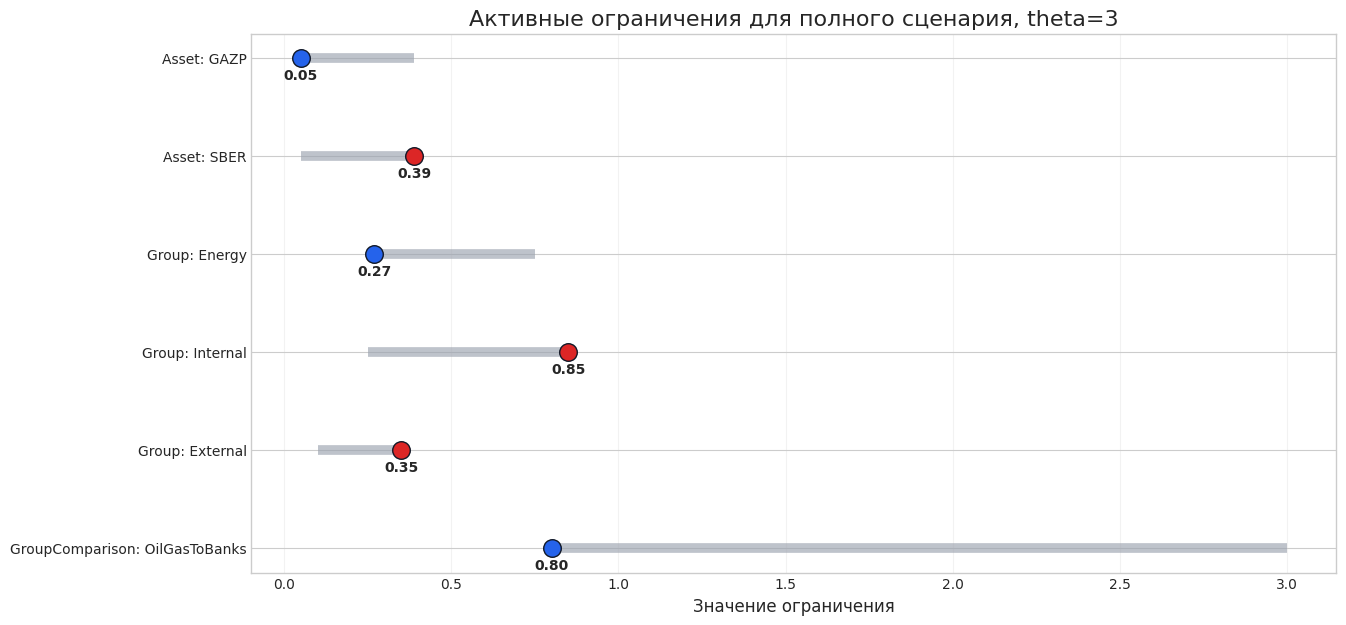

In [13]:
active_plot = active.copy()
active_plot["Label"] = active_plot["ConstraintType"] + ": " + active_plot["Name"]
y = np.arange(len(active_plot))

fig, ax = plt.subplots(figsize=(14, 7))
for idx, row in active_plot.reset_index(drop=True).iterrows():
    color = "#dc2626" if row["ActiveBound"] == "upper" else "#2563eb"
    ax.hlines(idx, row["LowerBound"], row["UpperBound"], color="#9ca3af", linewidth=7, alpha=0.65)
    ax.scatter(row["Value"], idx, s=160, color=color, edgecolor="#111827", zorder=3)
    ax.text(row["Value"], idx + 0.22, f"{row['Value']:.2f}", ha="center", fontsize=10, fontweight="bold")
ax.set_yticks(y)
ax.set_yticklabels(active_plot["Label"])
ax.set_xlabel("Значение ограничения")
ax.set_title("Активные ограничения для полного сценария, theta=3")
ax.grid(axis="x", alpha=0.25)
ax.invert_yaxis()

active_path = RESULTS_DIR / "infographic_active_constraints.png"
fig.savefig(active_path, dpi=180, bbox_inches="tight")
plt.show()


## Что означает коэффициент \(\xi\)

Коэффициент \(\xi\) — это доля капитала, вложенная в рискованный, или касательный, портфель:

\[
\xi = \sum_{i=1}^{n}x_i.
\]

Интерпретация:

- \(0 < \xi < 1\): часть капитала вложена в рискованный портфель, остаток — в безрисковый депозит;
- \(\xi = 1\): весь капитал вложен в рискованные активы;
- \(\xi > 1\): инвестор занимает деньги и увеличивает рискованную позицию;
- \(\xi < 0\): короткая позиция в рискованном портфеле, в этой постановке не возникает из-за ограничений \(x_i \ge 0.05\).

В основном варианте при \(\theta=2,3,4\) и полном наборе ограничений получилось \(\xi = 1.20\).
Значит, инвестор вкладывает 120% капитала в акции и финансирует дополнительные 20% за счёт заимствования.


## Итоговые выводы

1. По фактическим данным из Excel наибольшую выборочную ожидаемую доходность показали **SBER** и **VTBR**, а **GAZP** имеет отрицательную оценочную доходность.
2. Если оставить только индивидуальные ограничения, оптимизатор уходит в максимальное плечо: \(\xi=2.00\), почти все бумаги кроме GAZP находятся на верхней границе.
3. Групповые ограничения влияют сильнее всего: это видно и по таблице, и по инфографике активных ограничений — они снижают риск и доходность, ограничивают внешний/внутренний рынок и заставляют держать минимальную долю энергетики.
4. `GroupComparison` влияет слабее, но заметно перераспределяет доли между **LKOH** и **VTBR**.
5. При \(\theta=2,3,4\) итоговый портфель с полным набором ограничений совпадает, потому что активные ограничения оказываются сильнее изменения коэффициента неприятия риска.
6. При больших \(\theta\) портфель становится осторожнее: \(\xi\) снижается, а при \(\theta=40\) появляется положительная доля безрискового актива.
